In [6]:
import sys
from aqua import Reader

2023-09-02 18:58:11 :: Reader :: WARNING  -> No variables in the fixes for source lra-r100-monthly
2023-09-02 18:58:11 :: Reader :: WARNING  -> Returning the original variable


In [2]:
import sys
sys.path.insert(0, '../../')
from tropical_rainfall import Tropical_Rainfall

diag = Tropical_Rainfall(trop_lat=15,  num_of_bins = 1000, first_edge = 0, width_of_bin = 1, loglevel='error')


## lra

In [ ]:
reader = Reader(model='IFS', exp='historical-1990-devcon', source='lra-r100-monthly')
data = reader.retrieve(var="tprate") 
path_to_netcdf = "/work/bb1153/b382267/tropical_rainfall_cicle3/NetCDF/histograms/historical_1990_devcon_hourly_native/"
data = data*86400
data.tprate.attrs['units'] = 'mm/day'
diag.histogram(data, path_to_histogram=path_to_netcdf, threshold = 30,
                    name_of_file="ifs_control_1990_devcon_lra_r100_monthly")

In [ ]:
reader = Reader(model='IFS', exp='control-1950-devcon', source='lra-r100-monthly')
data = reader.retrieve(var="tprate") 
path_to_netcdf = "/work/bb1153/b382267/tropical_rainfall_cicle3/NetCDF/histograms/control_1950_devcon_hourly_native/"
data = data*86400
data.tprate.attrs['units'] = 'mm/day'
diag.histogram(data, path_to_histogram=path_to_netcdf, threshold = 30,
                    name_of_file="ifs_control_1950_devcon_lra_r100_monthly")

## 3hourly-data analysis on Lumi, script prototype

In [ ]:
import sys
from aqua import Reader

selected_year = sys.argv[1]
print(selected_year, 'Selected year')

# control-1950-devcon
reader = Reader(model='IFS', exp='historical-1990-devcon', source='hourly-native', aggregation='D', regrid="r010", freq='3H')
data = reader.retrieve(var="tprate", timmean=True, regrid=True, startdate=str(selected_year)+'0101', enddate=str(selected_year)+'1231:2300')

sys.path.insert(0, '../../')
from tropical_rainfall import Tropical_Rainfall

diag = Tropical_Rainfall(trop_lat=15,  num_of_bins = 1000, first_edge = 0, width_of_bin = 1, loglevel='error')

path_to_netcdf = "/users/nazarova/output/NetCDF/histograms/IFS/historical_1990_devcon_hourly_native/"

for dd in data:
    dd = dd*86400
    dd.tprate.attrs['units'] = 'mm/day'
    diag.histogram(dd, path_to_histogram=path_to_netcdf, threshold = 30,
                     name_of_file="ifs_control_1990_devcon_hourly_native_r010_3h")

## Plots

In [3]:
path_to_folder = '/work/bb1153/b382267/tropical_rainfall_cicle3/NetCDF/histograms/'

In [4]:
control_1950_devcon_hourly_native_lra = diag.open_dataset(path_to_folder+'control_1950_devcon_hourly_native/trop_rainfall_ifs_control_1950_devcon_lra_r100_monthly_1950-01-01T00_1959-12-01T00_histogram.nc')

In [5]:
historical_1990_devcon_hourly_native_lra = diag.open_dataset(path_to_folder+'historical_1990_devcon_hourly_native/trop_rainfall_ifs_control_1990_devcon_lra_r100_monthly_1990-01-01T00_1990-12-01T00_histogram.nc')

In [6]:
mswep_lra = diag.open_dataset(path_to_folder+'lra/trop_rainfall_mswep_past_monthly_r100_1979-02-01T00_2020-11-01T00_histogram.nc')

2023-09-02 23:02:49 :: create_folder :: WARNING  -> Folder /work/bb1153/b382267/tropical_rainfall_cicle3/PDF/histograms/ already exists


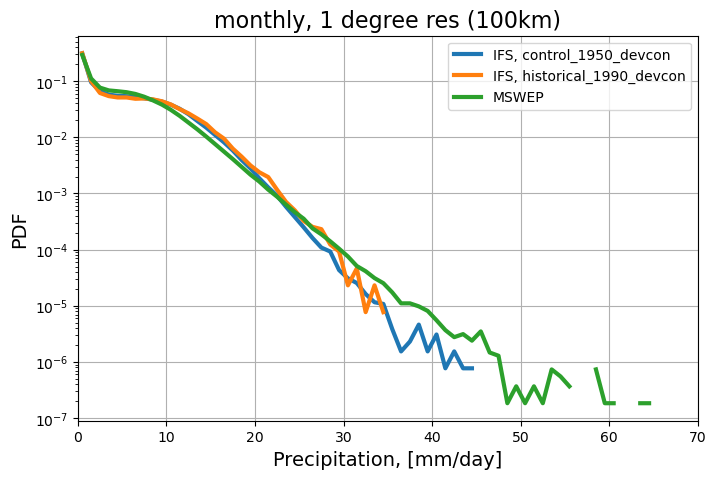

In [9]:
add = diag.histogram_plot(control_1950_devcon_hourly_native_lra,     figsize=1,                         
                legend='IFS, control_1950_devcon')
add = diag.histogram_plot(historical_1990_devcon_hourly_native_lra,       add = add,  color ='tab:orange', 
                legend='IFS, historical_1990_devcon') 
add = diag.histogram_plot(mswep_lra,        add = add,  color ='tab:green', 
                legend='MSWEP', 
                plot_title='monthly, 1 degree res (100km)', loc='upper right',
                path_to_pdf='/work/bb1153/b382267/tropical_rainfall_cicle3/PDF/histograms/', 
                pdf_format=False,  xmax = 70,
                name_of_file='aug_lra_comparison')

In [10]:
control_1950_devcon_hourly_native_3h_10km = diag.open_dataset(path_to_folder+'control_1950_devcon_hourly_native/trop_rainfall_GLOB_historical_1950_devcon_hourly_native_1950-01-01T00_1950-01-01T21_histogram.nc')

In [11]:
historical_1990_devcon_hourly_native_3h_10km = diag.open_dataset(path_to_folder+'historical_1990_devcon_hourly_native/trop_rainfall_GLOB_historical_1990_devcon_hourly_native_1990-01-01T00_1990-01-01T21_histogram.nc')

In [12]:
mswep_3h_10km = diag.open_dataset('/work/bb1153/b382267/tropical_rainfall_cicle3/NetCDF/histograms/mswep/trop_rainfall_GLOB_mswep_1979-01-01T09_2019-12-31T21_histogram.nc')

2023-09-02 23:03:22 :: create_folder :: WARNING  -> Folder /work/bb1153/b382267/tropical_rainfall_cicle3/PDF/histograms/ already exists


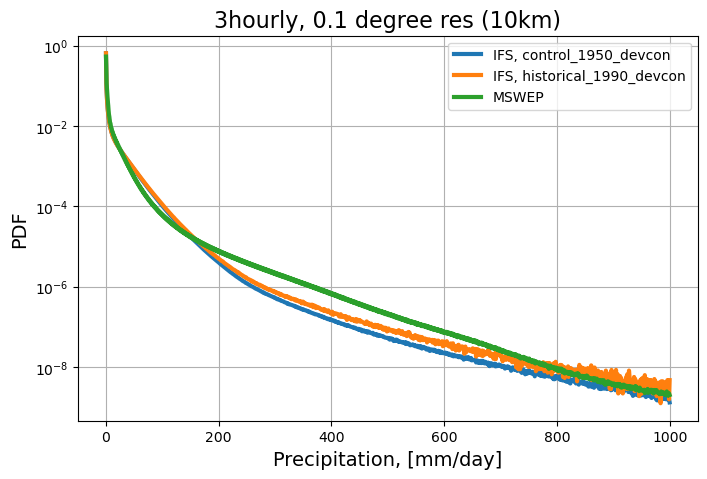

In [13]:
add = diag.histogram_plot(control_1950_devcon_hourly_native_3h_10km,     figsize=1,                         
                legend='IFS, control_1950_devcon')
add = diag.histogram_plot(historical_1990_devcon_hourly_native_3h_10km,       add = add,  color ='tab:orange', 
                legend='IFS, historical_1990_devcon') 
add = diag.histogram_plot(mswep_3h_10km,        add = add,  color ='tab:green', 
                legend='MSWEP', 
                plot_title='3hourly, 0.1 degree res (10km)', loc='upper right',
                path_to_pdf='/work/bb1153/b382267/tropical_rainfall_cicle3/PDF/histograms/', 
                pdf_format=False,  
                name_of_file='aug_3h_10km_comparison')